**Import packages and dependecies**

In [1]:
%pip install -q -e ..

Note: you may need to restart the kernel to use updated packages.


ERROR: file:///C:/Users/tcphan/OneDrive/Documents/Data%20Science%20Projects/topological does not appear to be a Python project: neither 'setup.py' nor 'pyproject.toml' found.


In [2]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

from tda.rips import VietorisRips
from tda.plotting import plot_barcode, plot_persistence_diagram

### 1. Load in data inputs

The Community-Level Health (CLH) database is maintained by the Agency for Healthcare Research and Quality (ARHQ). It provides data on healthcare outcomes and social determinants of health for geographic areas at a county, zip code, and census tract level. 

The fields in the CLH database can be categorized into 5 topic areas: 
1. Demographics (e.g. age, veteran status)
2. Economics (e.g. income, unemployment rate)
3. Education
4. Physical infrastructure (e.g.internet connectivity, food and excercise access)
5. Health (e.g. health providers, health conditions)

Users can download the raw data files here: https://www.ahrq.gov/data/innovations/clh-data.html

In [3]:
# Root location of project folders
root_path = str(Path.cwd().parent)

# Location of the CLH codebook file
codebook_path = fr"{root_path}\data\community_level_health_database\clh_2023_codebook_2_0.xlsx"
# Location of the CLH Excel file
data_path = fr"{root_path}\data\community_level_health_database\clh_2023_zipcode_2_0.xlsx"

# Read in codebook
codebook = pl.read_excel(codebook_path, sheet_name="Zipcode")

# Use codebook to derive data schema
schema = {}
for row in codebook.select(["Variable Name", "Type of Data (Numeric or Character)"]).to_dicts():
    schema[row["Variable Name"]] = "float" if row["Type of Data (Numeric or Character)"] == "num" else "string"

# Read in data
data = pl.read_excel(data_path, sheet_name="Data", read_options={"dtypes": schema})

In [4]:
# Show data
display(codebook)

Domain,Topic,Variable Name,Variable Label,Data Source,Type of Data (Numeric or Character),SAS Length,SAS Character,Position on the File
str,str,str,str,str,str,i64,str,i64
"""1. Demographics""","""Households""","""ACS_AVG_HH_SIZE_ZC""","""Average household size (ZCTA l…","""ACS""","""num""",8,"""12.2""",29
"""2. Economics""","""Income""","""ACS_GINI_INDEX_ZC""","""Gini index of income inequalit…","""ACS""","""num""",8,"""6.2""",181
"""2. Economics""","""Income""","""ACS_MDN_GRNDPRNT_INC_ZC""","""Median income of grandparent h…","""ACS""","""num""",8,"""16.2""",183
"""2. Economics""","""Income""","""ACS_MDN_GRNDPRNT_NO_PRNT_INC_Z…","""Median income of grandparent h…","""ACS""","""num""",8,"""16.2""",182
"""4. Physical infrastructure""","""Housing and mobility""","""ACS_MDN_OWNER_COST_MORTGAGE_ZC""","""Median selected monthly owner …","""ACS""","""num""",8,"""16.2""",242
…,…,…,…,…,…,…,…,…
"""6. Geography""","""""","""STATEFIPS""","""State FIPS Code (2-digit)""","""""","""char""",2,"""$2.""",2
"""6. Geography""","""""","""TERRITORY""","""Territory indicator (1= U.S. T…","""""","""num""",3,"""1.""",7
"""Identifier""","""""","""YEAR""","""File year""","""""","""num""",4,"""4.""",1


In [5]:
# Show data
display(data.head(10))

YEAR,STATEFIPS,ZIPCODE,ZCTA,STATE,REGION,TERRITORY,POINT_ZIP,ACS_TOT_POP_WT_ZC,ACS_TOT_POP_US_ABOVE1_ZC,ACS_TOT_POP_ABOVE5_ZC,ACS_TOT_POP_ABOVE15_ZC,ACS_TOT_POP_ABOVE16_ZC,ACS_TOT_POP_16_19_ZC,ACS_TOT_POP_ABOVE25_ZC,ACS_TOT_CIVIL_POP_ABOVE18_ZC,ACS_TOT_CIVIL_VET_POP_ABOVE25_ZC,ACS_TOT_OWN_CHILD_BELOW17_ZC,ACS_TOT_WORKER_NWFH_ZC,ACS_TOT_WORKER_HH_ZC,ACS_TOT_CIVILIAN_LABOR_ZC,ACS_TOT_CIVIL_EMPLOY_POP_ZC,ACS_TOT_CIVIL_NONINST_POP_POV_ZC,ACS_TOT_CIVIL_POP_POV_ZC,ACS_TOT_POP_POV_ZC,ACS_TOT_GRANDCHILDREN_GP_ZC,ACS_TOT_HU_ZC,ACS_TOT_HH_ZC,ACS_AVG_HH_SIZE_ZC,ACS_TOT_CIVIL_NONINST_POP_ZC,ACS_TOT_CIVIL_VET_POP_ZC,ACS_PCT_CHILD_DISAB_ZC,ACS_PCT_DISABLE_ZC,ACS_PCT_NONVET_DISABLE_18_64_ZC,ACS_PCT_VET_DISABLE_18_64_ZC,ACS_PCT_FEMALE_ZC,ACS_PCT_MALE_ZC,…,CCBP_TOT_FCRSC_ZP,CCBP_TOT_CHS_ZP,CCBP_TOT_CFS_ZP,CCBP_TOT_SFS_ZP,CCBP_TOT_EORS_ZP,CCBP_TOT_SHELTERS_ZP,CCBP_TOT_PHYS_ZP,CCBP_TOT_LAB_ZP,CCBP_TOT_RET_ZP,CCBP_TOT_HOME_ZP,CCBP_TOT_CHILD_ZP,CCBP_TOT_SA_ZP,CCBP_TOT_CS_ZP,CCBP_TOT_FF_ZP,CCBP_TOT_FSR_ZP,CCBP_TOT_SOGS_ZP,CEN_AREALAND_SQM_ZC,CEN_POPDENSITY_ZC,HHC_PCT_HHA_NURSING_ZP,HHC_PCT_HHA_PHYS_THERAPY_ZP,HHC_PCT_HHA_OCC_THERAPY_ZP,HHC_PCT_HHA_SPEECH_ZP,HHC_PCT_HHA_MEDICAL_ZP,HHC_PCT_HHA_AIDE_ZP,IHS_HEALTH_FACILITY,IHS_HEALTH_FACILITY_RATE,PC_PCT_MEDICARE_APPRVD_FULL_AMT,PC_PCT_MCARE_MAY_ACPT_APPRVD_AMT,POS_DIST_ED_ZP,POS_DIST_MEDSURG_ICU_ZP,POS_DIST_TRAUMA_ZP,POS_DIST_PED_ICU_ZP,POS_DIST_OBSTETRICS_ZP,POS_DIST_CLINIC_ZP,POS_DIST_ALC_ZP,CEN_AIAN_NH_IND,MISSING_ACS_DATA
i64,str,str,str,str,str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,i64,i64,f64,f64,f64,f64,f64,f64,…,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str
2023,"""01""","""35004""","""35004""","""Alabama""","""South""",0,0,11558,11419,10833,9271,9185,389,8405,8975,639,2112,4257,5355,5792,5424,11423,8975,11472,292,4801,4625,2.5,11509,639,1.93,15.21,12.61,4.08,51.6,48.4,…,null,null,null,null,null,null,null,null,null,null,null,4,7,8,null,3,17.24,670.47,null,null,null,null,null,null,null,null,94.44,5.56,9.81,11.3,15.4,29.7,9.81,9.83,18.39,"""0""","""0"""
2023,"""01""","""35005""","""35005""","""Alabama""","""South""",0,0,8143,8098,7805,6960,6893,325,6298,6659,484,1201,3743,3941,4196,3963,8085,6651,8085,203,3628,3116,2.6,8135,484,4.72,16.14,14.14,23.35,52.11,47.89,…,null,null,null,null,null,null,null,null,null,null,null,6,5,5,null,null,31.75,256.49,null,null,null,null,null,null,null,null,100.0,null,1.57,7.27,13.25,24.99,9.27,6.58,9.5,"""0""","""0"""
2023,"""01""","""35006""","""35006""","""Alabama""","""South""",0,0,3599,3574,3440,2976,2976,226,2610,2890,185,647,1568,1678,1724,1682,3599,2890,3599,41,1729,1296,2.78,3599,185,2.96,14.78,7.47,51.72,49.01,50.99,…,null,null,null,null,null,null,null,null,null,null,null,4,null,null,null,null,103.99,34.61,null,null,null,null,null,null,5,1.39,null,null,13.2,13.2,24.89,24.89,13.2,14.37,23.51,"""0""","""0"""
2023,"""01""","""35007""","""35007""","""Alabama""","""South""",0,0,27935,27536,26297,22081,21572,1151,18704,20758,1094,6223,11963,14221,14824,14209,27400,20408,27521,571,10634,10163,2.71,27459,1120,8.89,12.15,9.83,5.31,53.14,46.86,…,6,null,null,null,null,null,32,8,null,null,5,27,16,31,12,6,39.05,715.4,null,null,null,null,null,null,null,null,97.63,2.37,0.89,0.89,14.53,0.89,0.89,0.72,18.32,"""0""","""0"""
2023,"""01""","""35137""","""35007""","""Alabama""","""South""",0,1,27935,27536,26297,22081,21572,1151,18704,20758,1094,6223,11963,14221,14824,14209,27400,20408,27521,571,10634,10163,2.71,27459,1120,8.89,12.15,9.83,5.31,53.14,46.86,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,39.05,715.4,null,null,null,null,null,null,null,null,null,null,2.79,2.79,15.6,2.79,2.79,2.71,20.06,"""0""","""0"""
2023,"""01""","""35144""","""35007""","""Alabama""","""South""",0,1,27935,27536,26297,22081,21572,1151,18704,20758,1094,6223,11963,14221,14824,14209,27400,20408,27521,571,10634,1016

### 2. Preprocessing

**Remove columns with high missing rate**

In [6]:
# Initialize parameters
columns_list = data.columns
tot_n_rows = data.shape[0]
missing_threshold = 0.4 # Columns w/ missing rate less than or equal to threshold are kept

# Calculate the percent of missing in each column
missing_count_df = data.null_count()/tot_n_rows
missing_count_df = missing_count_df.unpivot(
    on=missing_count_df.columns,
    variable_name="Variable Name",
    value_name="p_missing"
)

# Merge on domain information
missing_count_df = (
    codebook.select(["Variable Name", "Domain"])
    .join(missing_count_df, on="Variable Name", how="left")
)


# Count the number of columns available in each domain before and after removing those that did not meet the missing rate threshold
all_columns_count_by_domain = (
    missing_count_df
    .group_by("Domain")
    .agg(
        pl.len().alias("tot_n_columns")
    )
)
missing_columns_count_by_domain = (
    missing_count_df.filter(pl.col("p_missing") <= missing_threshold)
    .group_by("Domain")
    .agg(
        pl.len().alias("n_columns_meet_threshold")
    )
)

# Final summary table showing the number of columns remaining
fin_columns_count_by_domain = (
    all_columns_count_by_domain
    .join(missing_columns_count_by_domain, on="Domain", how="left")
    .fill_null(0.0)
    .with_columns((pl.col("tot_n_columns") - pl.col("n_columns_meet_threshold")).alias("difference"))
    .sort(by=["Domain"])
)
fin_columns_count_by_domain.show()

# Remove columns from data
columns_failed_threshold_list = missing_count_df.filter(pl.col("p_missing") > missing_threshold).select("Variable Name").to_series()
preprocessed_data = data.select([c for c in columns_list if c not in columns_failed_threshold_list])

Domain,tot_n_columns,n_columns_meet_threshold,difference
str,f64,f64,f64
"""1. Demographics""",124.0,120.0,4.0
"""2. Economics""",81.0,69.0,12.0
"""3. Education""",10.0,10.0,0.0
"""4. Physical infrastructure""",87.0,66.0,21.0
"""5. Health""",41.0,31.0,10.0


### 3. Data Exploration with TDA

Often time, it can be difficult to visualize data when dealing with a large number of dimensions. Calculating Rips simplices and plotting their corresponding persistence graphs can be a useful method for capturing high-dimensional information in a compact 2-D diagram and quickly identifying clusters within a dataset. 

The example below walks through how you can apply TDA to compare health outcome data between two states. Health typically encompasses a variety of metrics and in this case, our data has a total of 41 possible features. In addition, even if states have similar average health outcomes, we can sometime miss that there are structural gaps or clusters that exist between zip codes when we aggregate upwards. TDA allows us to see whether structural differences in health outcomes exist among zip codes at a local level.

**Filter to state data**

We select two states of interest to compare their health outcome data. 

In [7]:
state1 = "North Dakota"
state2 = "New Mexico"
health_domain_variables = codebook.filter(pl.col("Domain") == "5. Health").select("Variable Name").to_series()

state_data_dict = {}
for state in [state1, state2]:

    print(f"\nState: {state}")
    print("-"*100)

    # Filter to data for the given state
    state_data = preprocessed_data.filter(pl.col("STATE") == state)
    print(f"Total # of records: {state_data.shape[0]:,}")

    # Get list of variables belonging to the Health domain
    state_data = state_data.select([c for c in state_data.columns if c in health_domain_variables])
    print(f"# of columns in Health domain: {len(state_data.columns):,}")

    # Remove row if it has NaN for at least one column
    state_data = state_data.drop_nulls()
    print(f"# of records remaining after filtering out NaN: {state_data.shape[0]:,}")

    state_data_dict[state] = state_data



State: North Dakota
----------------------------------------------------------------------------------------------------
Total # of records: 407
# of columns in Health domain: 31
# of records remaining after filtering out NaN: 400

State: New Mexico
----------------------------------------------------------------------------------------------------
Total # of records: 427
# of columns in Health domain: 31
# of records remaining after filtering out NaN: 393


**Calculate Rips simplices**

In TDA, 0-dimensional simplices represent the number of disconnected componenets, 1-dimensional simplices represent the number of "holes", and 2-dimensional simplices represent "voids".

In [8]:
n_dimensions = 2 # Number of dimensions to calculate simplices for
max_epsilon = 50.0 # The maximum distance between each data point to consider

rips_config_dict = {}
for state, state_data in state_data_dict.items():
    
    print(f"\nState: {state}")
    print("-"*100)

    # Calculate Rips simplices
    rips_config = VietorisRips(max_dim=n_dimensions, max_epsilon=max_epsilon)
    rips_config.fit_transform(state_data)

    for i in range(n_dimensions+1):
        print(f"# of simplices for {i}-th dimension: {len(rips_config.get_simplices_for_dim(dim=i)):,}")

    rips_config_dict[state] = rips_config


State: North Dakota
----------------------------------------------------------------------------------------------------
# of simplices for 0-th dimension: 400
# of simplices for 1-th dimension: 9,064
# of simplices for 2-th dimension: 124,897

State: New Mexico
----------------------------------------------------------------------------------------------------
# of simplices for 0-th dimension: 393
# of simplices for 1-th dimension: 4,104
# of simplices for 2-th dimension: 42,811


**Calculate and plot persistence pairs**

Looking first at the red H0 dots in the Persistence Diagram for each state, we see that the dots for North Dakota have noticeable separations in their placement at around Death = 5.0 and Death = 10.0 that splits the red dots into 3 major sections. The H0 dots for New Mexico are much more continous and lacking any overt separations. This suggests that North Dakota may have more local pockets or clusters of zip codes with persistent differences in their health outcomes whereas New Mexico's health data is more homogenous and evenly distributed across the state. 

Looking next at the blue H1 triangles, we see that New Mexico's triangles deviate more from the dash diagonal line than those of North Dakota. This suggests that for North Dakota, any multi-dimensional loops that form are short-lived or can be considered mostly "topological noise". Arizona has more signifcant "loops" or complex structural differences in its health outcomes space. There are specific combinations of health outcomes that no zip codes in New Mexico possess, wrapped around by zip codes that do, in order to form topological "holes" in its health outcomes space.

Taking these observations together, we can conclude that local differences in health outcomes exist for both states but the underlyiing factors driving North Dakota's differences tend to interact more linearly while those same factors may operate more non-linearly in New Mexico. For instance, as socioeconomic factors shift in North Dakota, health outcomes may shift in a predictable and straightforward linear manner. For New Mexico, those same factors may improve health outcomes up to a certain point then diminish gradually or even cause health outcomes to reverse course. New Mexico's health outcomes cannot be captured as simply using linear models as North Dakota's might be. This tells us that we may have to apply different fundamental models or approaches when it comes to predicting health outcomes for North Dakota and New Mexico.


State: North Dakota
----------------------------------------------------------------------------------------------------


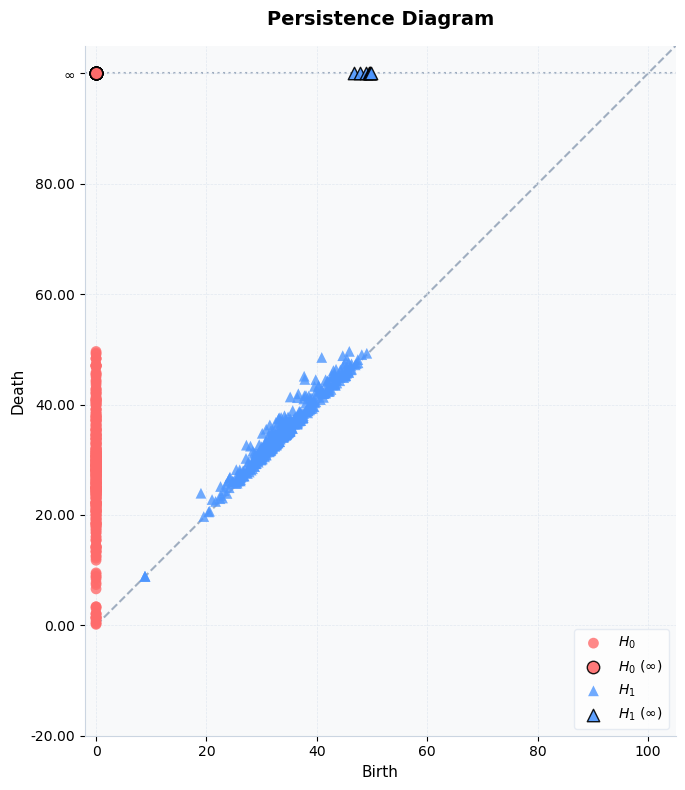


State: New Mexico
----------------------------------------------------------------------------------------------------


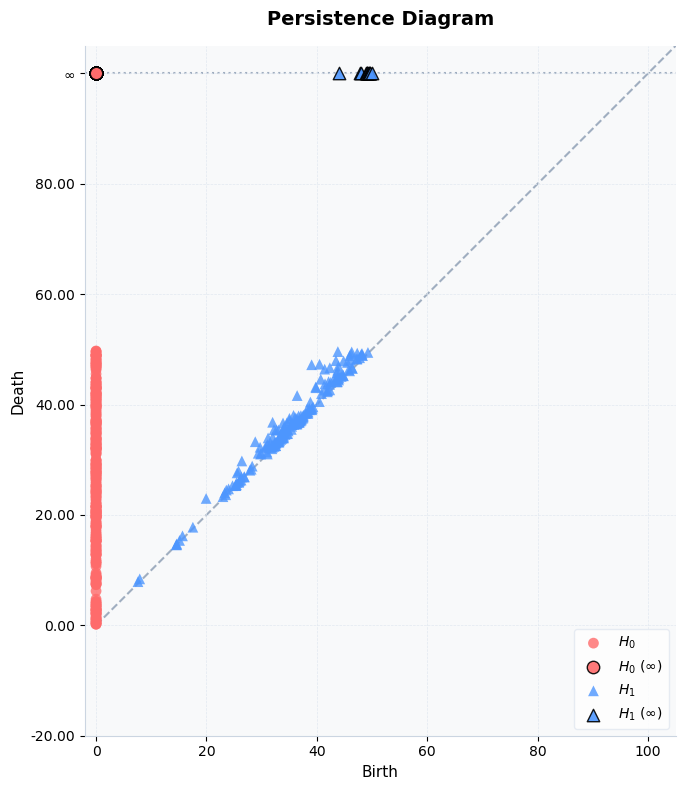

In [9]:
for state, rips_config in rips_config_dict.items():

    print(f"\nState: {state}")
    print("-"*100)

    # Calculate birth-death pairs
    birth_death_by_dimension = rips_config.compute_birth_death_pairs()

    # Plot a persistence plot showcasing the birth and death time of each simplex in each dimension
    fig, ax = plt.subplots(figsize=(8, 8)) 
    plot_persistence_diagram(birth_death_by_dimension, max_limit=100, ax=ax, show=False)
    plt.show()